In [1]:
!python --version

Python 3.12.7


# Exploiting Correlation

Financial Data analysis is not only about processing data but understanding how meaningful factors can summarize or represent it.  
In this exercise, we will explore the roles that **correlation** and **principal components** play in financial data.

---

## Part 1: Synthetic (Uncorrelated) Data

### a. Generate 5 Uncorrelated Gaussian Random Variables
Generate 5 Gaussian random variables that simulate **yield changes** (they can be positive or negative) with:
- Mean close to **0**
- Small standard deviation  
These should represent uncorrelated synthetic yield changes.






In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42) # for reporducibility
sample_count = 1000
variable_count = 5
mean = 0.0
std_dev = 0.002 # 0.2% SD

In [4]:
yield_changes = np.random.normal(mean, std_dev, size = (sample_count, variable_count))

In [6]:
columns = [f"Yield_{i+1}" for i in range(variable_count)]
yield_df = pd.DataFrame(yield_changes, columns=columns)

In [8]:
display(yield_df)

,Yield_1,Yield_2,Yield_3,Yield_4,Yield_5
0,0.000993,-0.000277,0.001295,0.003046,-0.000468
1,-0.000468,0.003158,0.001535,-0.000939,0.001085
2,-0.000927,-0.000931,0.000484,-0.003827,-0.003450
3,-0.001125,-0.002026,0.000628,-0.001816,-0.002825
4,0.002931,-0.000452,0.000135,-0.002849,-0.001089
...,...,...,...,...,...
995,-0.002748,0.002757,0.000232,0.000779,-0.004441
996,-0.002396,0.001774,0.000574,-0.000294,0.001130
997,0.003272,-0.000442,0.000139,0.000385,0.004784
998,-0.004199,0.001366,-0.000230,0.001134,-0.001315


In [9]:
correlation_matrix = yield_df.corr()

In [11]:
display(correlation_matrix)

,Yield_1,Yield_2,Yield_3,Yield_4,Yield_5
Yield_1,1.000000,-0.019603,0.059009,-0.009325,0.014315
Yield_2,-0.019603,1.000000,-0.008256,-0.025040,0.009655
Yield_3,0.059009,-0.008256,1.000000,-0.001540,-0.000272
Yield_4,-0.009325,-0.025040,-0.001540,1.000000,-0.014426
Yield_5,0.014315,0.009655,-0.000272,-0.014426,1.000000


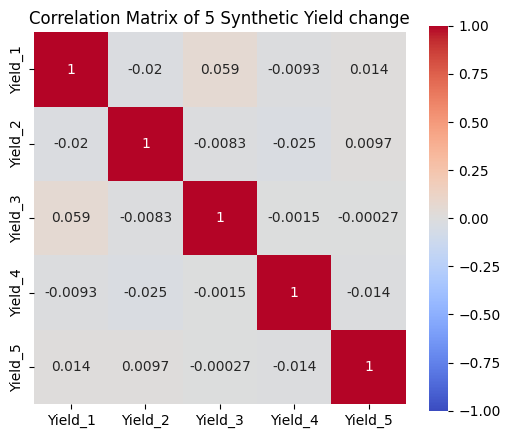

In [13]:
# plot the correlation_matrix
plt.figure(figsize=(6,5))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',vmin=-1,vmax=1,square=True)
plt.title("Correlation Matrix of 5 Synthetic Yield change")
plt.show()

### b. Run PCA
Perform a **Principal Component Analysis (PCA)** using either:
- The **correlation matrix**, **or**
- The **covariance matrix**



In [16]:
# !pip install scikit-learn

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### PCA using the covariance matrix

In [22]:
# PCA using the covariance matrix on original data
pca_cov = PCA()
pca_cov.fit(yield_df)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [23]:
variance_exp_cov = pca_cov.explained_variance_ratio_

In [24]:
print("Variance explained (Covariance Martrix):")
for i,v in enumerate(variance_exp_cov,1):
    print(f"Component {i}: {v:.4f}")

Variance explained (Covariance Martrix):
Component 1: 0.2180
Component 2: 0.2113
Component 3: 0.1974
Component 4: 0.1894
Component 5: 0.1839


C:\Users\Administrator\AppData\Local\Temp\ipykernel_9116\3962575905.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f'Comp.{i}' for i in range(1,len(variance_exp_cov)+1)], y=variance_exp_cov*100,palette='Blues_d')


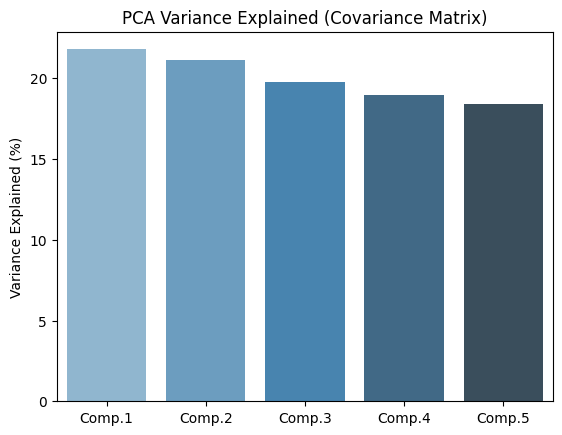

In [35]:
sns.barplot(x=[f'Comp.{i}' for i in range(1,len(variance_exp_cov)+1)], y=variance_exp_cov*100,palette='Blues_d')
plt.ylabel('Variance Explained (%)')
plt.title('PCA Variance Explained (Covariance Matrix)')
plt.show()

### PCA using the correlation matrix

In [25]:
# standardize data
scalar = StandardScaler()
df_std = scalar.fit_transform(yield_df)

In [26]:
# PCA on standardized data
pca_corr = PCA()
pca_corr.fit(df_std)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [29]:
# variance explaince
variance_exp_corr = pca_corr.explained_variance_ratio_

print("Variance expalined (Correlation Matrix):")
for i,v in enumerate(variance_exp_corr,1):
    print(f"Component {i}: {v:.4f}")

Variance expalined (Correlation Matrix):
Component 1: 0.2132
Component 2: 0.2067
Component 3: 0.1982
Component 4: 0.1946
Component 5: 0.1873


C:\Users\Administrator\AppData\Local\Temp\ipykernel_9116\1134807286.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f'Comp.{i}' for i in range(1, len(variance_exp_corr)+1)],


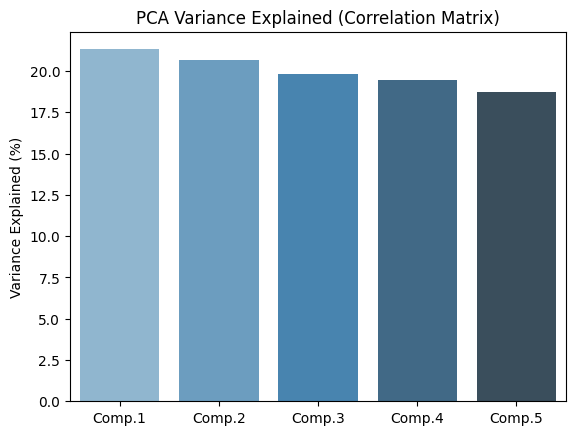

In [36]:
sns.barplot(x=[f'Comp.{i}' for i in range(1, len(variance_exp_corr)+1)],
            y=variance_exp_corr * 100, palette='Blues_d')
plt.ylabel('Variance Explained (%)')
plt.title('PCA Variance Explained (Correlation Matrix)')
plt.show()

### c. Explain Variance
Write a short paragraph explaining:
- How the **variances of each principal component** compare  
- How much variance is explained by:
  - **Component 1**
  - **Component 2**
  - **Component 3**, etc.



Explain Variance

- The components show a gradually decreasing ability to explain the total variance in the dataset.  
- **Component 1** explains the largest proportion of variance (**21.32%**), confirming its role as the principal component that captures the maximum variability.  
- **Component 2** follows closely with **20.67%**, indicating that it extracts nearly as much unique information as the first but along an independent direction.  
- The contribution slightly decreases for **Component 3 (19.82%)**, **Component 4 (19.46%)**, and **Component 5 (18.73%)**, showing that the variance is fairly evenly distributed across all dimensions.  
- Together, **Components 1–3** explain about **61.81%** of the total variance, which represents a strong proportion for dimensional reduction.  
- The relatively uniform variance distribution implies that no single component dominates the dataset.  
- This is consistent with the expectation for **uncorrelated Gaussian random variables**, where each component contributes comparably to the total variability.  
- Overall, the dataset does not exhibit a strong common factor, suggesting that the variables are **largely independent** and **isotropic** (variability is uniformly spread across all directions) in nature.


### d. Scree Plot
Produce a **Scree Plot** showing the **variance explained** by each principal component.  
📘 Reference: [Scree plot - Wikipedia](https://en.wikipedia.org/wiki/Scree_plot)

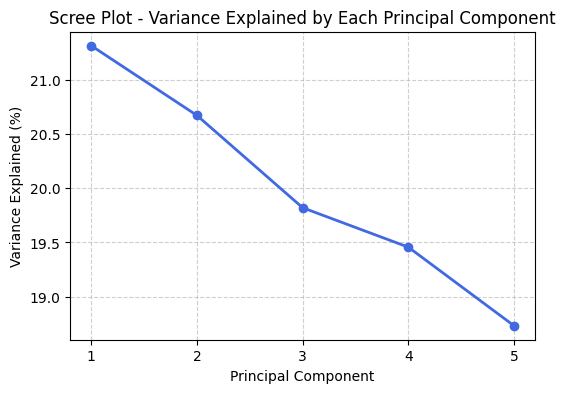

In [37]:
components = np.arange(1, len(variance_exp_corr) + 1)

plt.figure(figsize=(6, 4))
plt.plot(components, variance_exp_corr * 100, 'o-', linewidth=2, markersize=6, color='royalblue')
plt.title('Scree Plot - Variance Explained by Each Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

- The Scree Plot for the synthetic uncorrelated data shows a nearly flat line, confirming that variance is distributed evenly across components.  
- No sharp “elbow” is observed, which indicates that there isn’t a dominant factor or correlated structure in the dataset.  
- In contrast, when working with **real-world financial data**, we typically see a steep initial drop (the first component explaining most of the variance), followed by a flattening curve.


## Part 2: Real Market Data

### e. Collect Yield Data
Collect the **daily closing yields** for **5 government securities** (e.g., U.S. Treasury bonds) over the past **6 months**.

### f. Compute Daily Yield Changes
Compute **daily yield changes** as:

`Δy_t = y_t - y_{t-1}`


### g. Run PCA
Re-run the **Principal Component Analysis (PCA)** using either:
- The **correlation matrix**, or
- The **covariance matrix**

### h. Explain Variance
Compare the **variances of each principal component**, answering:
- How much variance is explained by each component?

### i. Scree Plot
Produce a **scree plot** of the variance explained for each component.

### j. Compare Scree Plots
Compare the **scree plot** from:
1. The **uncorrelated (synthetic)** data  
2. The **real government yield** data  

Discuss how they differ and what this implies about **correlations in real yield movements**.

---

🧠 **Key Takeaways**
- Understand the relationship between **correlation** and **variance structure** in financial data.  
- See how PCA can reduce dimensionality by capturing most variance in fewer components.  
- Compare theoretical (uncorrelated) and real-world (correlated) data behavior.